# HOPCo Data Analyst (Statistics) Stage 2 Task
**Author: Shi Min Chua**  
## Description
This document is the main output for the task. Related source codes and more detailed notes could be found in data_exploration, which could be messy but serves as an appendix. Here I only focused more crucial issues while other trivial data issues were documented in the appendix spreadsheet and notebook

### 1. How I understand the dataset

- As I am not familiar with data from this field and it is an open-ended exploration, I first went through each table to understand each column, looking for primary key, foreign keys, potential relevant columns in the table, unique values, most frequent values, null values in each column.

In [ ]:
-- Sample queries used for going through each column in each table
-- Check number of rows in a table
SELECT * FROM patient_journey

-- Check for null values
-- for column containing categorical data of char type */
SELECT content_slug
FROM activity
WHERE (content_slug IS NULL or content_slug = '');
-- for column containing numeric data
SELECT schedule_id
FROM activity
WHERE (schedule_id IS NULL);

-- for categorical variables, to check for most frequency category and its count. 
SELECT
	content_slug, 
	COUNT(content_slug) AS content_count
FROM
	activity
GROUP BY
	content_slug
ORDER BY
	content_count DESC

-- see sheet named tables in appendix for notes

- With data model introduced in the instructions and the above inspection, I drew out ERD for the database.
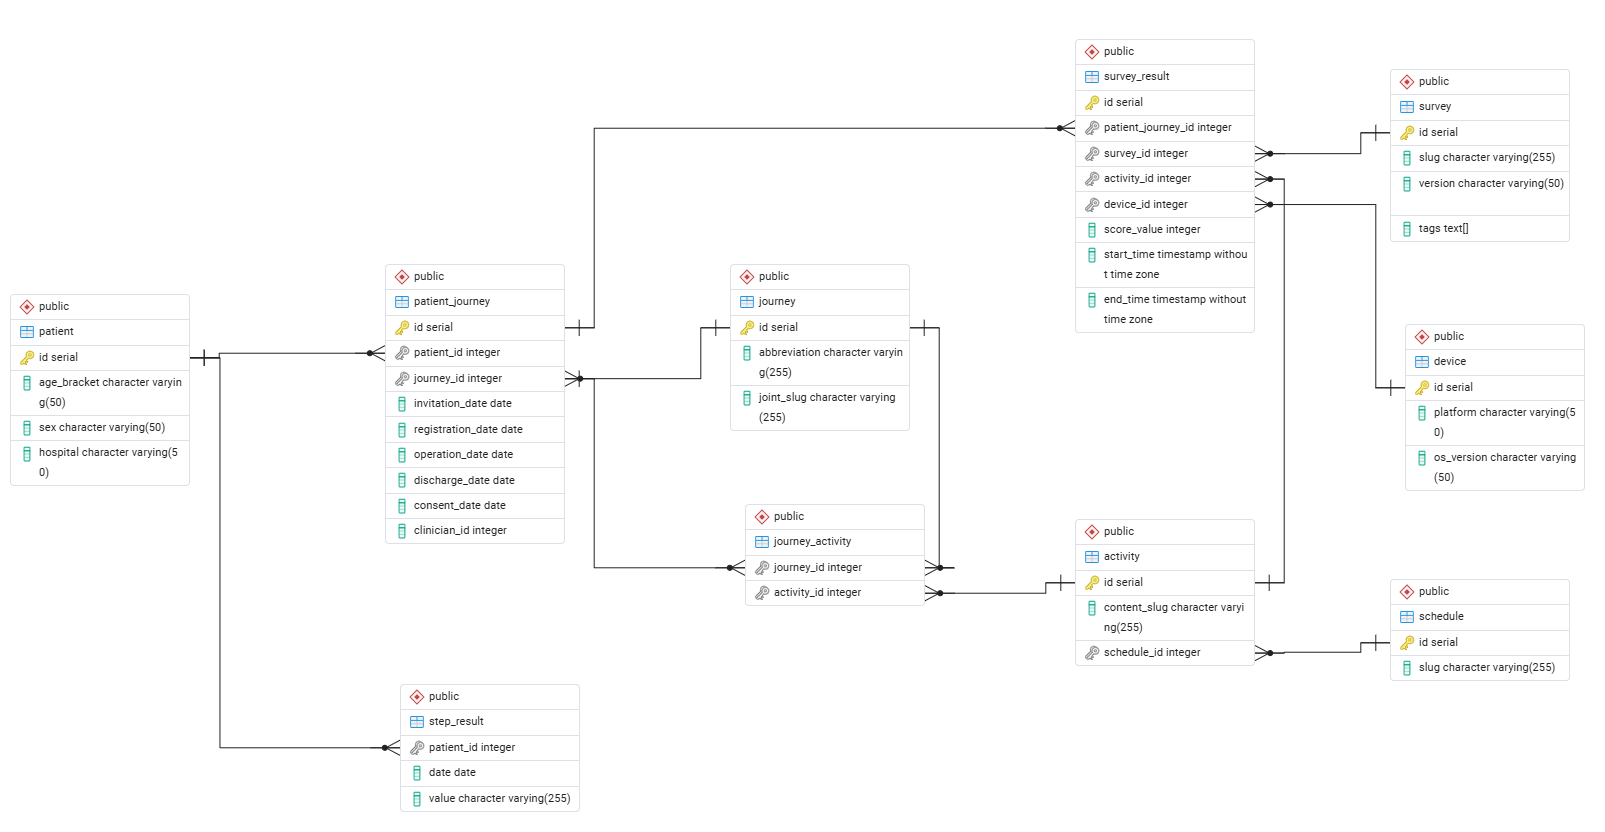


- After quite a few investigation relating various tables, I created a master data file joining most of the tables by left joining to the `survey_result` table because this table consisted of score of survey which could be an indication of recovery. Particularly, score of the same survey conducted before and after an operation as a measure of improvement/change. The `value` in the `step_result` table (likely the improvement of step count between the value first recorded and the one last recorded). Therefore, it seems that only patients who have data point in the `survey_result` and `step_result` could be included to investigate features/factors that influence recovery. And we could take the `survey_result` as the 'master file' for the other tables to join with.

    Admittedly, a master data file could be slow to process but it helps me to do open-ended exploration especially to see the most frequent values of each variables in the dataset,and examine relationships between variables. I also made sure I only include relevant variables and in fact the queries of the master file is not slow. 

In [ ]:
--- Creating the master data file with only relevant fields. 
CREATE VIEW master_data AS
SELECT survey_result.id,
		patient_id,
		patient_journey_id,
		abbreviation AS journey,
		sex,
		hospital,
		clinician_id,
		survey.slug AS survey_slug,
		score_value,
		operation_date,
		--derived date from the timestamp, assuming the timezone would be similar to those of milestone dates. 
		DATE(end_time) AS survey_date,
		schedule.slug AS schedule_slug,
		discharge_date,
		registration_date
		FROM survey_result
		LEFT JOIN activity ON survey_result.activity_id = activity.id
		LEFT JOIN schedule ON activity.schedule_id = schedule.id
		LEFT JOIN survey ON survey_result.survey_id = survey.id
		LEFT JOIN patient_journey ON survey_result.patient_journey_id = patient_journey.id
		LEFT JOIN journey ON patient_journey.journey_id = journey.id
		LEFT JOIN patient ON patient_journey.patient_id = patient.id


- Features that could predict outcomes, for example patient-reported health outcomes
1. patient's individual characteristics: sex, age (could be included if the time-shift does not result in huge range of change in the age)
2. Hospital and clinician
3. Step count before operations. I have not got time to check if there is such data in step count. This could indicate initial health condition. 
4. `journey_order`: I derived this variable for each patient_journey to determine if this operation is the first, second etc operation for patient. It is likely having operation before may compromise their recovery. However, we might lack of operation not recorded in the database.

In [ ]:
CREATE VIEW journey_order AS
SELECT patient_journey_id,
row_number() OVER (PARTITION BY patient_id ORDER BY operation_date) AS journey_order
FROM (SELECT patient_id, patient_journey_id, operation_date
	FROM master_data
	GROUP BY patient_id, patient_journey_id, operation_date)

--if operation date is null, it will rank after those with operation date


5. Other potential features: Some surveys might be measureing some general individual characteristics like health habit or socio-economic factors that have long been associated with health outcome.. But I don't have information about the survey in the data. I hypothesis the 'onboaring-surv' might be relevant.
6. days after the operation: it is likely the patient will get better across the time after the operation. I derived the variables below. 
7. Body-part undergoing operation: the `joint_slug` seems to indicate the body-part but largely null. It could be easily derived from the corresponding `abbreviation` by regex but I run out of time and I most likely will just focus on one operation in the analysis to narrow down focus. So do not need it. 
8. Time-varying features: As some survey is taken multiple times after the operations, it is possible to include them in a mixed-effect model as a time-varying features but the idiosyncrasy of the timing of completing the survey across patients might be hard to incorporate into a model. 

### 2. Data Issues and decisions made

#### No data dictionary
It would be nice to have data dictionary to understand the fields and values of some potential relevant variables.
- survey: The scale, purpose, and whether the higher score means better health will be essential for analysis. For example, some survey may be useful to establish patient characteristics, rather than tracking outcomes. I checked those most used in the datasets so as to get an understanding. Additionally, I have been investigating if certain survey is associated with certain schedule and operations, which seems so.

- `hospital`: The code could mean individual hospitals or categories of hospital, especially nowadays there are different types of healthcare services, e.g., day-care, in-patient, out-patient, private, government. Similar thinking applies to `clinician_id`.

- Whether certain values could be grouped together: For example, Knee replacement, Bilateral knee replacement, unicompartmental knee replacement etc may be grouped together if focus is on overall body part operation. 


#### Schedule
I assumed the `operation_date` is correct and it is recorded for most of the data, and I also assumed the `end_time` indicate the completion date of a survey and extract `survey_date` fomr it. Therefore, beside the `schedule`, I could also derive variables, including a categorical variable to indicate if a survey is conducted pre-op or post-op, how many days since operation to know when a survey score indicates outcome after operation or baselines before operations. 

64% of the rows in my master file are missing `schedule_slug`, and some surveys which based on my derived variables are in conflict with the `schedule_slug` such that pre- or post-op could differ and the date the survey is conducted could be out of range of the schedule. Therefore, I decided to use my derived variables to determine when a survey is conducted in relation to operation date. 

The table below shows where I extract post-op, pre-op and post-reg from schedule slug and cross-tabulated with the 3 categories based on the date of the survey and operations, showing the conflicting nature of the schedule. I would relate post-reg to pre-op in my definition, although I have concerns about the clinical/practical significance of post-reg and pre-op that might explain why they exist to start with. 
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>pre_post_based_on_schedule</th>
      <th>{post-op}</th>
      <th>{post-reg}</th>
      <th>{pre-op}</th>
    </tr>
    <tr>
      <th>pre_post_based_on_date</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>post-op</th>
      <td>28975</td>
      <td>6213</td>
      <td>268</td>
    </tr>
    <tr>
      <th>pre-op</th>
      <td>998</td>
      <td>14173</td>
      <td>18111</td>
    </tr>
    <tr>
      <th>same-day</th>
      <td>157</td>
      <td>457</td>
      <td>530</td>
    </tr>
  </tbody>
</table>
</div>



In [ ]:
-- derived variables in relation to time the survey is done in relation to operation.
CREATE VIEW master_data_derived AS
SELECT master_data.id,
		patient_id,
		master_data.patient_journey_id,
		journey_order,
		journey,
		sex,
		hospital,
		clinician_id,
		survey_slug,
		score_value,
		schedule_slug,
		-- create a categorical var to determine pre, post-op based on the operation date and survey date
			CASE
				WHEN operation_date < survey_date THEN 'post-op'
				WHEN operation_date > survey_date THEN 'pre-op'
				WHEN operation_date = survey_date THEN 'same-day'
				ELSE NULL
			END AS pre_post_based_on_date,
		-- capture pre-op, post-op and post-reg from the schedule_slug
		regexp_match(schedule_slug,'pre-op|post-op|post-reg')::varchar AS pre_post_based_on_schedule,
		operation_date,
		survey_date,
		-- calculate the number of days since operation, minus means the survey is done before survey
		survey_date - operation_date AS day_since_operation
		FROM master_data
		-- join journey_order to get the order of each patient journey
		LEFT JOIN journey_order ON master_data.patient_journey_id=journey_order.patient_journey_id


#### Outcome measures
- to define complete recovery
Because the instruction asks for recovery time for patients after surgery, we need a cut-off score for any of the outcome measures to be define as complete recovery. If we are using step count, we have to either use normative data for each patient based on their age group or more specifically to the patients' condition. This might require experts' input. Similarly for any patient-reported outcome survey. 

    Another way of looking at recovery is a progress-perspective rather than a cut-off, i.e., how much progress/improvement made is considered recovery. In this case, if we are using step count, we will need to decide how many step improvement must be reached to be considered recovery. similar reasoning for other survey measures.


- A universal measure
To consider all data in one model, we would need ameasure that is universally recorded for all patient_journey. 

    Survey used in the dataset could be quite specific to certain operations, and as shown in the chart below there is no one survey used across all journey, although 'hopco_standardcore-pain-surv', 'pain-meds-surv', 'pain-surv' are widely used in the dataset.

    Therefore, we either need a behavioural measure (such as step count) that patients are willing to record for universal measure or a survey generic enough for all types of patients. However, even step count might not apply for some operation which mainly affect hand etc. So it is likely we need different measures for different operations. 


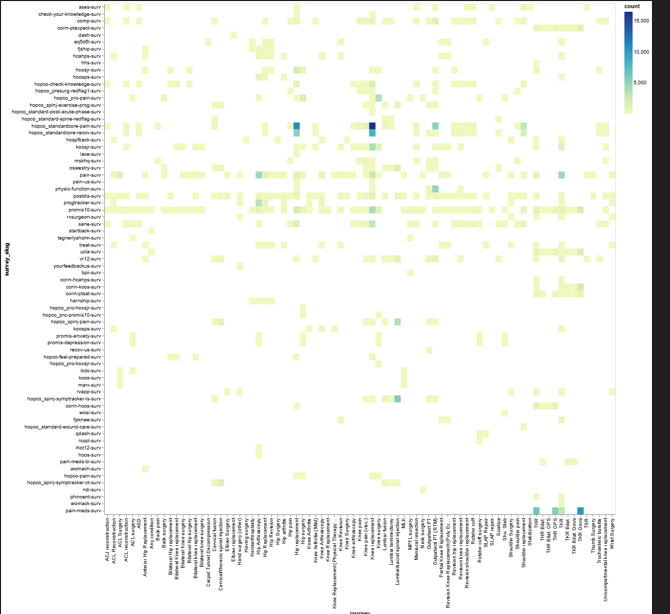

Sorry that I could not put the scrollable heatmap here as it was too big to be loaded. Basically this heatmap showed crosstab of survey and journey, so in a single glance, we could easily see if there is any single survey used across all journey

#### Step result
Since step result could be an indicator of recovery, and without any exterior criteria, we could use data-driven strategy to decide on the cut-off point as the complete recovery. Assuming the last few recorded step count of the patient is the successful recovery (that is why they could stop recording), we could take an average score of the last 3 record (average to avoid any day variations). Here I only focus on knee operation patients as different types of patients might have different step count. 


In [ ]:
-- get the patient_id of those undergoing knee replacement
CREATE VIEW knee_patient AS
	SELECT DISTINCT(patient_id) 
	FROM master_data_derived_no_null
	WHERE journey = 'Knee replacement'

-- extract the step results from those patient to reduce the size of table to be used. 
CREATE VIEW knee_patient_step AS
SELECT step_result.patient_id,
	step_result.date AS step_date,
	step_result.value AS step_count
FROM knee_patient 
LEFT JOIN step_result ON knee_patient.patient_id = step_result.patient_id

-- extract the last 3 steps only for average purposes. similar way to create the first 3 step count
CREATE VIEW last_3_step AS
WITH  CTE  AS (
  SELECT *, ROW_NUMBER()  OVER (PARTITION BY  patient_id  ORDER BY  step_date DESC)  AS  row_num
  FROM
    knee_patient_step
)
SELECT * FROM CTE WHERE row_num <= 3;

-- average the last 3 steps and also get the last date of record, similar way to create first 3 step count
CREATE VIEW last_ave_step AS
SELECT * FROM
	(
	SELECT *,
	avg(CAST(step_count AS INT)) OVER (PARTITION BY patient_id)
	FROM last_3_step
	)
WHERE row_num = 1

I plotted a histogram of the average first 3 steps and average last 3 steps of the knee patients to decide on the step count that is considered complete recovery. It is an arbitrary decision. And it is interesting to see that before the operation, they function well, and it seems the operation affect them more and require more time to recover. So perhaps I will take 1250 step as the recovery threshold. I also look into the step change as another measure, but it looks completed as some seems to deteriorate while other improve

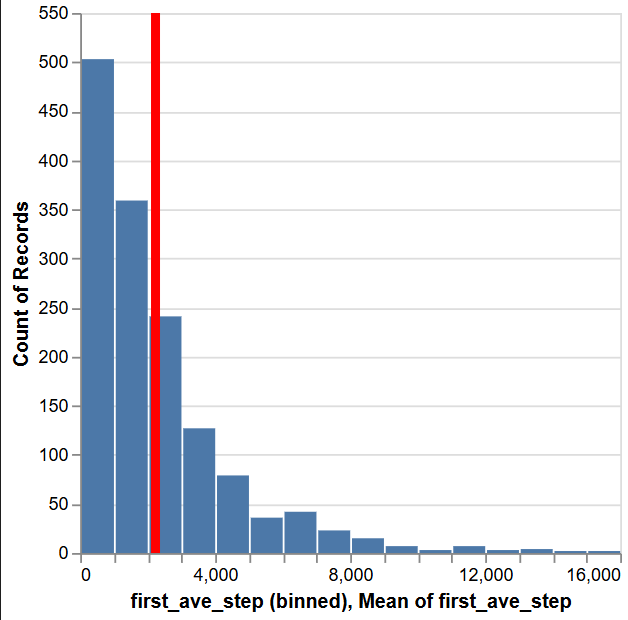
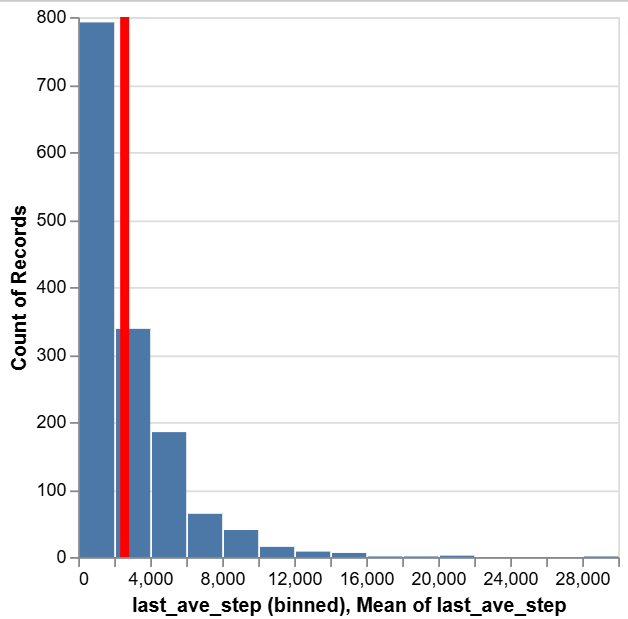

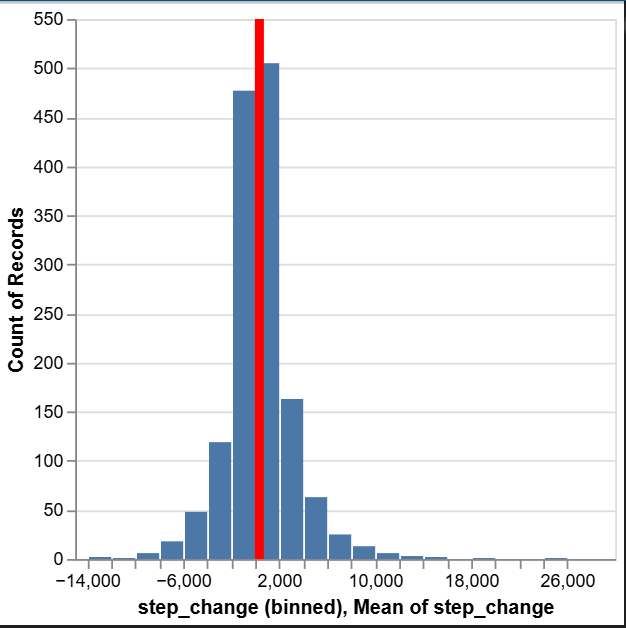

#### Statistical analysis

I will extract step count data again and only get those rows hitting the 1250 steps, while those not will be classified as not yet recovered. 

There are two models that can be conducted:
1. logistic regression with those hitting the step cut-off as success, and those did not as fail. Features are those mentioned above
2. Linear regression model focusing on those hitting the step cut-off only but with the number of days since operation as the outcome measures. Another model could be run with step count change as an outcome measures.


I have also been thinking about mixed-effect modelling given that we could find the growth rate of step change as well as some surveys that have been repeatedly measures. However, the inconsistency of the data, i.e., some patients did more times on a survey and and some don't, and how to organise the data may require more time. 

### Additional thoughts
I think the main challenge is that patients undergoing the same type of journey still do not necessarily go through the same surveys not to mention the schedule. I guess this is real world data. Another problem is that we don't know if this difference is because the patients just do not do the surveys, that might also be an indication of the patient's characteristics. So it might be good to have record about patients missing/not doing the survey rather than just not recorded.  

My approach to understand this messiness is to find the most frequent values and then delve into it. I also look into a random sample of patient data to see their journey to get an understanding. 

Additionally, it seems all the surveys are patient-report and along with step count are all contributed by patients. I am aware of the movement of patient-focused healthcare, but I wonder if we could get more 'objective' clinical data about the patients, as assessed by doctors during the patient journey and hopefully likely to be recorded like EHR data. 





#### Extra
To be honest, I actually misread the instructions about estimation for faster recovery to just predict better outcomes. So I have been looking for a survey that has been measured before and after an operation so that we could compare the improvement, then use that survey score as the outcome measure to run a multiple regression model. I used only those going through 'Knee replacement' 

what I did:
1. I created two tables,
    - one with pre-op survey only and calculated the average of score if a survey is administered more than once, so as to create a reliable score;
    - another with post-op survey only and take the last score of the survey if the it is administered once, assuming the latest score reflect the best of the patient outcome. 

2. I then join the table so that I could get the survey that are measured before and after the operation. To some extent, this helps me to know which surveys are the priority in the data set and in the clinical setting. 

3. Then I could conduct regression by focusing on each survey measure as y once at a time and use the average pre-op score to control for baseline. 

4. See prediction ipynb though I could not complete in time.


In [ ]:
--average pre_score for knee replacement
CREATE VIEW pre_op_knee AS
	SELECT patient_id, 
		patient_journey_id,
		survey_pre,
		journey_order,
		journey,
		sex,
		hospital,
		clinician_id,
		avg(score_value_pre) AS ave_pre_score
		FROM pre_op_sur
		WHERE journey = 'Knee replacement'
		GROUP BY patient_id, 
		patient_journey_id,
		survey_pre,
		journey_order,
		journey,
		sex,
		hospital,
		clinician_id


-- last score for post op (including other operation but will be knee replacement after inner join with pre_op)
CREATE VIEW post_op_knee AS
	SELECT *
	FROM
		(
		SELECT *,
			-- put 1 into the last score based on date for each survey
			row_number() OVER (PARTITION BY patient_journey_id, survey_post ORDER BY survey_date_post DESC) AS last_post_score
			FROM post_op_sur
		)
	WHERE last_post_score = 1

